# Exploratory Data Analysis of Customer Segmentation and Subscription Behaviour in a Telecommunication Marketing Campaign

In [1]:
#importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency
import scipy.stats as stats

In [2]:
#mounting drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
#importing data into colab
df = pd.read_csv('/content/drive/MyDrive/STATS/TeleCom_Data-1.csv')
df

,"age;""job"";""marital"";""education"";""default"";""housing"";""loan"";""contact"";""month"";""day_of_week"";""duration"";""campaign"";""pdays"";""previous"";""poutcome"";""emp.var.rate"";""cons.price.idx"";""cons.conf.idx"";""euribor3m"";""nr.employed"";""y"""
0,"40;""admin."";""married"";""basic.6y"";""no"";""no"";""no..."
1,"56;""services"";""married"";""high.school"";""no"";""no..."
2,"45;""services"";""married"";""basic.9y"";""unknown"";""..."
3,"59;""admin."";""married"";""professional.course"";""n..."
4,"41;""blue-collar"";""married"";""unknown"";""unknown""..."
...,...
41175,"29;""unemployed"";""single"";""basic.4y"";""no"";""yes""..."
41176,"73;""retired"";""married"";""professional.course"";""..."
41177,"46;""blue-collar"";""married"";""professional.cours..."
41178,"56;""retired"";""married"";""university.degree"";""no..."


In [4]:
# The file uses semicolon (;) as separator
df = pd.read_csv('/content/drive/MyDrive/STATS/TeleCom_Data-1.csv', sep=';')
df

,"age;""job"";""marital"";""education"";""default"";""housing"";""loan"";""contact"";""month"";""day_of_week"";""duration"";""campaign"";""pdays"";""previous"";""poutcome"";""emp.var.rate"";""cons.price.idx"";""cons.conf.idx"";""euribor3m"";""nr.employed"";""y"""
0,"40;""admin."";""married"";""basic.6y"";""no"";""no"";""no..."
1,"56;""services"";""married"";""high.school"";""no"";""no..."
2,"45;""services"";""married"";""basic.9y"";""unknown"";""..."
3,"59;""admin."";""married"";""professional.course"";""n..."
4,"41;""blue-collar"";""married"";""unknown"";""unknown""..."
...,...
41175,"29;""unemployed"";""single"";""basic.4y"";""no"";""yes""..."
41176,"73;""retired"";""married"";""professional.course"";""..."
41177,"46;""blue-collar"";""married"";""professional.cours..."
41178,"56;""retired"";""married"";""university.degree"";""no..."


In [5]:
# Let's check how file looks like before loading
with open('/content/drive/MyDrive/STATS/telecom_clean.csv', 'r') as f:
    for i, line in enumerate(f):
        print(repr(line))
        if i == 2:
            break

'age;"job";"marital";"education";"default";"housing";"loan";"contact";"month";"day_of_week";"duration";"campaign";"pdays";"previous";"poutcome";"emp.var.rate";"cons.price.idx";"cons.conf.idx";"euribor3m";"nr.employed";"y"\n'
'40;"admin.";"married";"basic.6y";"no";"no";"no";"telephone";"may";"mon";151;1;999;0;"nonexistent";1.1;93.994;-36.4;4.857;5191;"no"\n'
'56;"services";"married";"high.school";"no";"no";"yes";"telephone";"may";"mon";307;1;999;0;"nonexistent";1.1;93.994;-36.4;4.857;5191;"no"\n'


In [6]:
# The file has extra quotes wrapping each line
cleaned_lines = []
with open('/content/drive/MyDrive/STATS/TeleCom_Data-1.csv', 'r', encoding='utf-8') as f:
    for line in f:
        line = line.strip()
        line = line.strip('"')
        line = line.replace('""', '"')
        line = line + '"'
        cleaned_lines.append(line)

# Save cleaned version and reload
with open('/content/drive/MyDrive/STATS/telecom_clean.csv', 'w', encoding='utf-8') as f:
    f.write('\n'.join(cleaned_lines))

df = pd.read_csv('/content/drive/MyDrive/STATS/telecom_clean.csv', sep=';')
df = df.rename(columns={'y': 'subscribed'}) #renaming target variable for convenience

print(type(df))
print("Number of rows and columns:", df.shape)
df.head()

<class 'pandas.core.frame.DataFrame'>
Number of rows and columns: (41180, 21)


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,subscribed
0,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,45,services,married,basic.9y,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,59,admin.,married,professional.course,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,41,blue-collar,married,unknown,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [7]:
#renaming difficult columns for legitibility
df = df.rename(columns={
    'emp.var.rate': 'emp_variation_rate',
    'cons.price.idx': 'consumer_price_idx',
    'cons.conf.idx': 'consumer_conf_idx',
    'euribor3m': 'euribor_3month',
    'nr.employed': 'num_employed'
})
print("Updated columns:", df.columns.tolist())

Updated columns: ['age', 'job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'emp_variation_rate', 'consumer_price_idx', 'consumer_conf_idx', 'euribor_3month', 'num_employed', 'subscribed']


##1. Data Error Detection

In [8]:
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp_variation_rate,consumer_price_idx,consumer_conf_idx,euribor_3month,num_employed,subscribed
0,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,45,services,married,basic.9y,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,59,admin.,married,professional.course,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,41,blue-collar,married,unknown,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [9]:
print(df['poutcome'].value_counts())

poutcome
nonexistent    35559
failure         4250
success         1371
Name: count, dtype: int64


In [10]:
df.tail()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp_variation_rate,consumer_price_idx,consumer_conf_idx,euribor_3month,num_employed,subscribed
41175,29,unemployed,single,basic.4y,no,yes,no,cellular,nov,fri,...,1,9,1,success,-1.1,94.767,-50.8,1.028,4963.6,no
41176,73,retired,married,professional.course,no,yes,no,cellular,nov,fri,...,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,yes
41177,46,blue-collar,married,professional.course,no,no,no,cellular,nov,fri,...,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,no
41178,56,retired,married,university.degree,no,yes,no,cellular,nov,fri,...,2,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,no
41179,44,technician,married,professional.course,no,no,no,cellular,nov,fri,...,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,yes


In [11]:
df.shape

(41180, 21)

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41180 entries, 0 to 41179
Data columns (total 21 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   age                 41180 non-null  int64  
 1   job                 41180 non-null  object 
 2   marital             41180 non-null  object 
 3   education           41180 non-null  object 
 4   default             41180 non-null  object 
 5   housing             41180 non-null  object 
 6   loan                41180 non-null  object 
 7   contact             41180 non-null  object 
 8   month               41180 non-null  object 
 9   day_of_week         41180 non-null  object 
 10  duration            41180 non-null  int64  
 11  campaign            41180 non-null  int64  
 12  pdays               41180 non-null  int64  
 13  previous            41180 non-null  int64  
 14  poutcome            41180 non-null  object 
 15  emp_variation_rate  41180 non-null  float64
 16  cons

In [13]:
df.describe()

,age,duration,campaign,pdays,previous,emp_variation_rate,consumer_price_idx,consumer_conf_idx,euribor_3month,num_employed
count,41180.000000,41180.000000,41180.000000,41180.000000,41180.000000,41180.000000,41180.000000,41180.000000,41180.000000,41180.000000
mean,40.021710,258.280427,2.567800,962.516707,0.172705,0.081901,93.575508,-40.501999,3.621422,5167.053344
std,10.419593,259.299856,2.770225,186.809028,0.493719,1.571037,0.578762,4.627358,1.734385,72.230334
min,17.000000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000
25%,32.000000,102.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000
50%,38.000000,180.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.000000,319.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,98.000000,4918.000000,56.000000,999.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


In [14]:
# Checking unique values of categorical columns for anything unexpected
print("\nUnique values in 'subscribed':", df['subscribed'].unique())
print("Unique values in 'contact':", df['contact'].unique())
print("Unique values in 'marital':", df['marital'].unique())
print("Unique values in 'poutcome':", df['poutcome'].unique())
print("Unique values in 'day_of_week':", df['day_of_week'].unique())
print("Unique values in 'month':", df['month'].unique())


Unique values in 'subscribed': ['no' 'yes']
Unique values in 'contact': ['telephone' 'cellular']
Unique values in 'marital': ['married' 'single' 'divorced' 'unknown']
Unique values in 'poutcome': ['nonexistent' 'failure' 'success']
Unique values in 'day_of_week': ['mon' 'tue' 'wed' 'thu' 'fri']
Unique values in 'month': ['may' 'jun' 'jul' 'aug' 'oct' 'nov' 'dec' 'mar' 'apr' 'sep']


In [15]:
print(df['pdays'].value_counts())

pdays
999    39667
3        439
6        411
4        118
9         64
2         61
7         60
12        58
10        52
5         46
13        36
11        28
1         25
15        24
14        20
8         18
0         15
16        11
17         8
18         7
22         3
19         3
21         2
25         1
26         1
27         1
20         1
Name: count, dtype: int64


In [16]:
# Replacing pdays = 999 with -1 as per data dictionary
df['pdays'] = df['pdays'].replace(999, -1)
print(df['pdays'].value_counts())

pdays
-1     39667
 3       439
 6       411
 4       118
 9        64
 2        61
 7        60
 12       58
 10       52
 5        46
 13       36
 11       28
 1        25
 15       24
 14       20
 8        18
 0        15
 16       11
 17        8
 18        7
 22        3
 19        3
 21        2
 25        1
 26        1
 27        1
 20        1
Name: count, dtype: int64


In [17]:
# Calls with 0 duration means customer was never reached
print("\nCalls with 0 duration:", (df['duration'] == 0).sum())


Calls with 0 duration: 4


In [18]:
#  Removing 0 duration calls as they can not lead in subscription
df = df[df['duration'] > 0]
print("\nCalls with 0 duration:", (df['duration'] == 0).sum())


Calls with 0 duration: 0


In [19]:
print("\nRows after removing 0 duration calls:", df.shape[0])


Rows after removing 0 duration calls: 41176


In [20]:
print("\nMax campaign contacts:", df['campaign'].max())
print("Campaign contacts > 10:", (df['campaign'] > 10).sum())


Max campaign contacts: 56
Campaign contacts > 10: 869


In [21]:
# Checking for outliers in numeric columns
print("Campaign max:", df['campaign'].max())
print("Campaign mean:", df['campaign'].mean().round(2))

print("\nDuration max:", df['duration'].max(), "seconds")
print("Duration mean:", df['duration'].mean().round(2), "seconds")

print("\nPrevious max:", df['previous'].max())
print("Previous mean:", df['previous'].mean().round(2))

Campaign max: 56
Campaign mean: 2.57

Duration max: 4918 seconds
Duration mean: 258.31 seconds

Previous max: 7
Previous mean: 0.17


##2. Missing Value Analysis

In [22]:
# Checking for missing values in each column
missing_values = df.isnull().sum()
print("Missing values per column:")
print(missing_values)

Missing values per column:
age                   0
job                   0
marital               0
education             0
default               0
housing               0
loan                  0
contact               0
month                 0
day_of_week           0
duration              0
campaign              0
pdays                 0
previous              0
poutcome              0
emp_variation_rate    0
consumer_price_idx    0
consumer_conf_idx     0
euribor_3month        0
num_employed          0
subscribed            0
dtype: int64


In [23]:
# Looking into 'unknown' values in categorical columns
print("Unknown counts per column:")
for col in df.select_dtypes(include='object').columns:
    count = (df[col] == 'unknown').sum()
    if count > 0:
        print(f"  {col}: {count} unknowns ({count/len(df)*100:.1f}%)")

Unknown counts per column:
  job: 330 unknowns (0.8%)
  marital: 80 unknowns (0.2%)
  education: 1731 unknowns (4.2%)
  default: 8596 unknowns (20.9%)
  housing: 990 unknowns (2.4%)
  loan: 990 unknowns (2.4%)


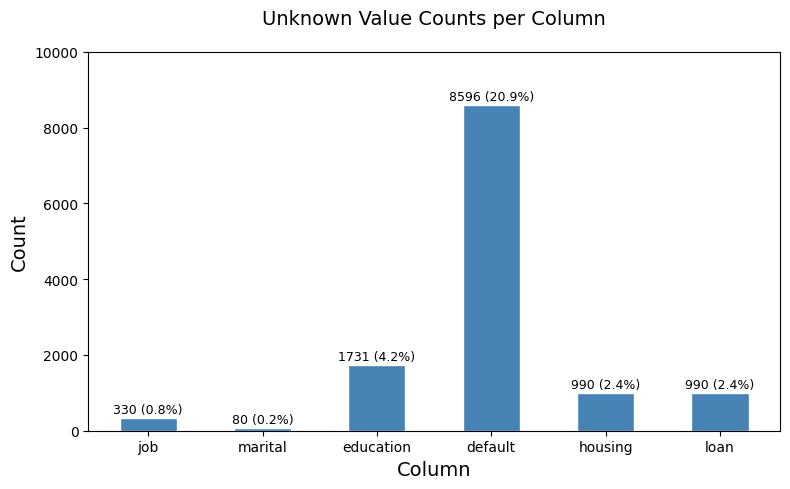

In [24]:
plt.figure(figsize=(8, 5))

unknown_counts = {}
for col in df.select_dtypes(include='object').columns:
    count = (df[col] == 'unknown').sum()
    if count > 0:
        unknown_counts[col] = count

bars = plt.bar(unknown_counts.keys(), unknown_counts.values(),
               color='steelblue', edgecolor='white', width=0.5)

# Add value labels on bars
for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
             f'{int(bar.get_height())} ({int(bar.get_height())/len(df)*100:.1f}%)',
             ha='center', va='bottom', fontsize=9)

plt.title('Unknown Value Counts per Column', fontsize=14, pad=20)
plt.xlabel('Column', fontsize=14)
plt.ylabel('Count', fontsize=14)
plt.ylim(0, 10000)
plt.tight_layout()
plt.show()

In [25]:
# Fill unknown values with mode for small percentages
for col in ['job', 'marital', 'housing', 'loan', 'education']:
    mode_value = df[col][df[col] != 'unknown'].mode()[0]
    df[col] = df[col].replace('unknown', mode_value)
    print(f"{col} unknowns filled with mode: {mode_value}")

# Keep unknown as category for default as too many to impute
print("\ndefault - keeping unknown as category")

print("\nShape after handling unknowns:", df.shape)

job unknowns filled with mode: admin.
marital unknowns filled with mode: married
housing unknowns filled with mode: yes
loan unknowns filled with mode: no
education unknowns filled with mode: university.degree

default - keeping unknown as category

Shape after handling unknowns: (41176, 21)


In [26]:
print("Unknown counts after handling:")
for col in df.select_dtypes(include='object').columns:
    count = (df[col] == 'unknown').sum()
    print(f"  {col}: {count}")

Unknown counts after handling:
  job: 0
  marital: 0
  education: 0
  default: 8596
  housing: 0
  loan: 0
  contact: 0
  month: 0
  day_of_week: 0
  poutcome: 0
  subscribed: 0


#3. Descriptive Statistics

In [27]:
# Summary statistics for numeric variables
df.describe().round(2)

,age,duration,campaign,pdays,previous,emp_variation_rate,consumer_price_idx,consumer_conf_idx,euribor_3month,num_employed
count,41176.00,41176.00,41176.00,41176.00,41176.00,41176.00,41176.00,41176.00,41176.00,41176.00
mean,40.02,258.31,2.57,-0.74,0.17,0.08,93.58,-40.50,3.62,5167.05
std,10.42,259.30,2.77,1.51,0.49,1.57,0.58,4.63,1.73,72.23
min,17.00,1.00,1.00,-1.00,0.00,-3.40,92.20,-50.80,0.63,4963.60
25%,32.00,102.00,1.00,-1.00,0.00,-1.80,93.08,-42.70,1.34,5099.10
50%,38.00,180.00,2.00,-1.00,0.00,1.10,93.75,-41.80,4.86,5191.00
75%,47.00,319.00,3.00,-1.00,0.00,1.40,93.99,-36.40,4.96,5228.10
max,98.00,4918.00,56.00,27.00,7.00,1.40,94.77,-26.90,5.04,5228.10


In [28]:
# Summary statistics for categorical variables
df.describe(include='object')

,job,marital,education,default,housing,loan,contact,month,day_of_week,poutcome,subscribed
count,41176,41176,41176,41176,41176,41176,41176,41176,41176,41176,41176
unique,11,3,7,3,2,2,2,10,5,3,2
top,admin.,married,university.degree,no,yes,no,cellular,may,thu,nonexistent,no
freq,10751,24998,13896,32577,22558,34929,26137,13763,8622,35555,36538


In [29]:
# Value counts for each categorical variable
cat_cols = ['job', 'marital', 'education', 'default', 'housing', 'loan',
            'contact', 'month', 'day_of_week', 'poutcome', 'subscribed']

for col in cat_cols:
    print(f"\n{col}:")
    print(df[col].value_counts())


job:
job
admin.           10751
blue-collar       9251
technician        6742
services          3967
management        2922
retired           1718
entrepreneur      1456
self-employed     1421
housemaid         1059
unemployed        1014
student            875
Name: count, dtype: int64

marital:
marital
married     24998
single      11568
divorced     4610
Name: count, dtype: int64

education:
education
university.degree      13896
high.school             9511
basic.9y                6043
professional.course     5241
basic.4y                4175
basic.6y                2292
illiterate                18
Name: count, dtype: int64

default:
default
no         32577
unknown     8596
yes            3
Name: count, dtype: int64

housing:
housing
yes    22558
no     18618
Name: count, dtype: int64

loan:
loan
no     34929
yes     6247
Name: count, dtype: int64

contact:
contact
cellular     26137
telephone    15039
Name: count, dtype: int64

month:
month
may    13763
jul     7174
aug     617

In [30]:
print("Subscription rate:")
print(df['subscribed'].value_counts())
print("\nPercentage:")
print(df['subscribed'].value_counts(normalize=True).round(3) * 100)

Subscription rate:
subscribed
no     36538
yes     4638
Name: count, dtype: int64

Percentage:
subscribed
no     88.7
yes    11.3
Name: proportion, dtype: float64


#Section 4: Distribution Plots

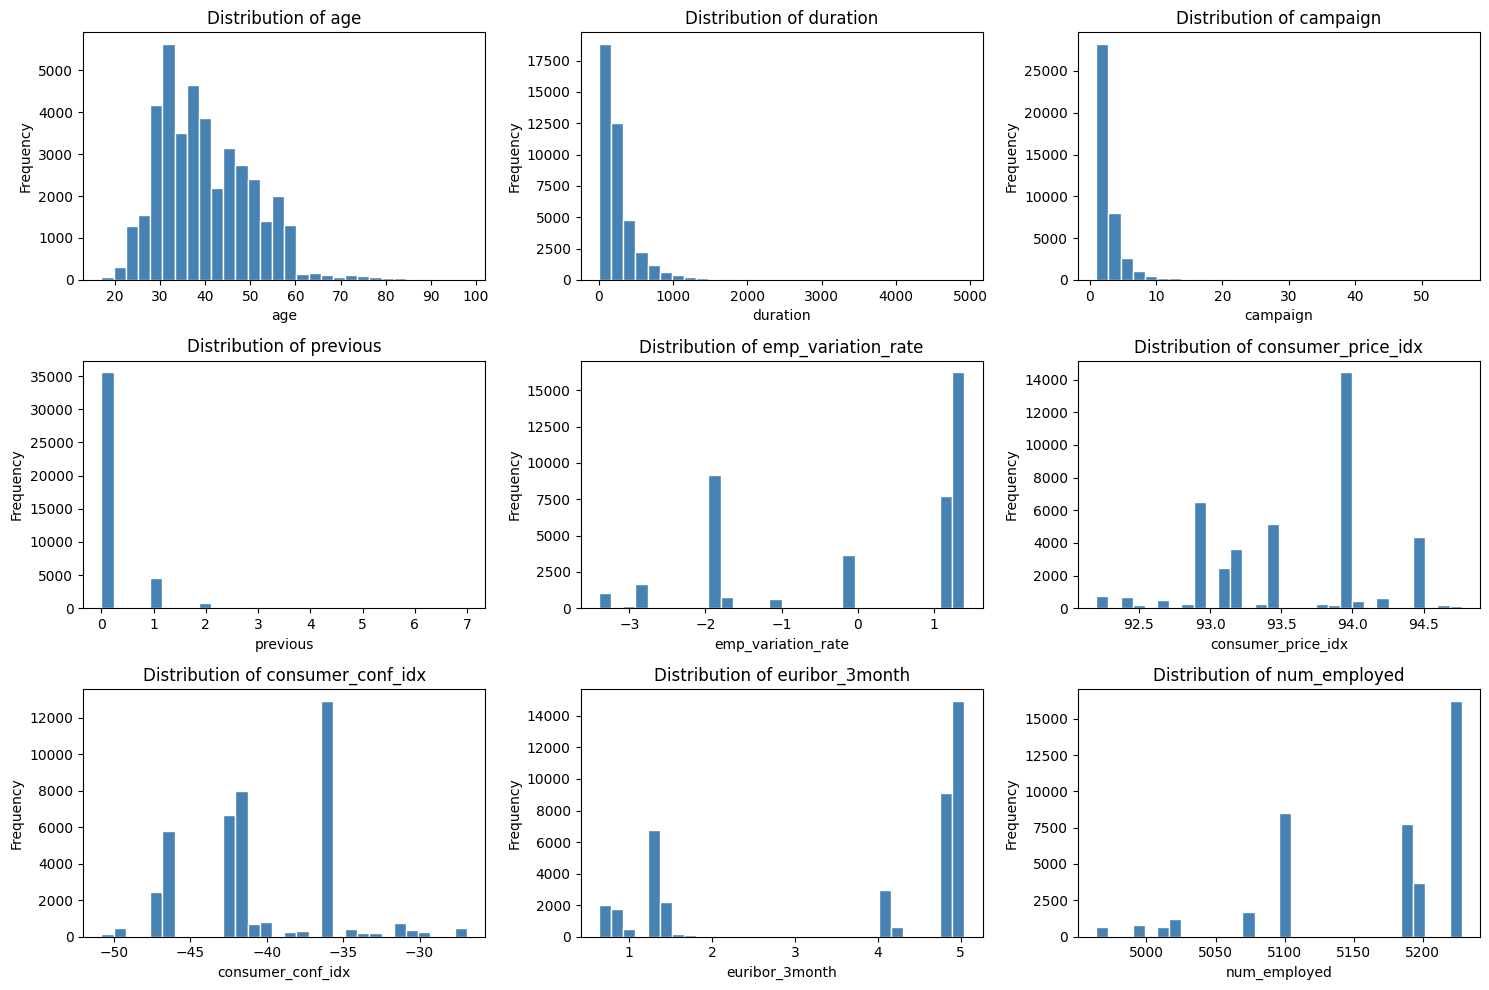

In [31]:
numeric_cols = ['age', 'duration', 'campaign', 'previous', 'emp_variation_rate',
                'consumer_price_idx', 'consumer_conf_idx', 'euribor_3month', 'num_employed']

fig, axes = plt.subplots(3, 3, figsize=(15, 10))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    axes[i].hist(df[col], bins=30, color='steelblue', edgecolor='white')
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

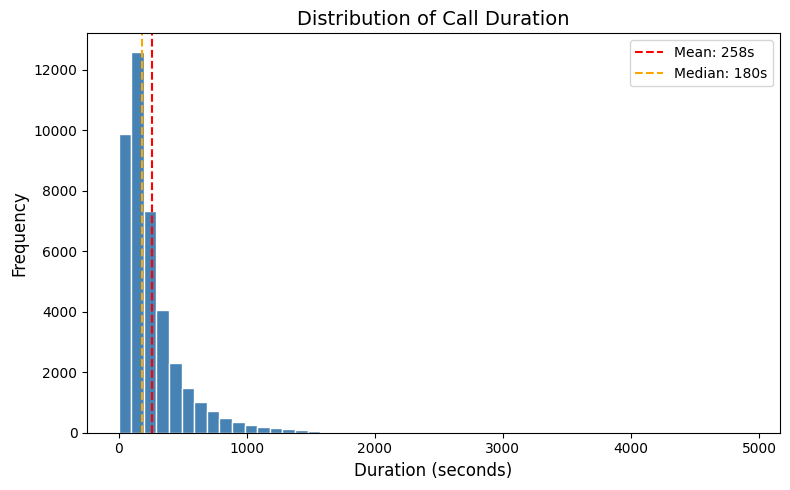

In [32]:
plt.figure(figsize=(8, 5))

plt.hist(df['duration'], bins=50, color='steelblue', edgecolor='white')
plt.title('Distribution of Call Duration', fontsize=14)
plt.xlabel('Duration (seconds)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.axvline(df['duration'].mean(), color='red', linestyle='--', label=f'Mean: {df["duration"].mean():.0f}s')
plt.axvline(df['duration'].median(), color='orange', linestyle='--', label=f'Median: {df["duration"].median():.0f}s')
plt.legend()
plt.tight_layout()
plt.show()

In [33]:
# Skewness and Kurtosis of numeric variables
print(f"{'Variable':<25} {'Skewness':>10} {'Kurtosis':>10}")
print("-" * 47)
for col in numeric_cols:
    skew = df[col].skew().round(2)
    kurt = df[col].kurt().round(2)
    print(f"{col:<25} {skew:>10} {kurt:>10}")

Variable                    Skewness   Kurtosis
-----------------------------------------------
age                             0.78       0.79
duration                        3.26      20.25
campaign                        4.76      36.98
previous                        3.81      19.78
emp_variation_rate             -0.72      -1.06
consumer_price_idx             -0.23      -0.83
consumer_conf_idx                0.3      -0.36
euribor_3month                 -0.71      -1.41
num_employed                   -1.04       -0.0


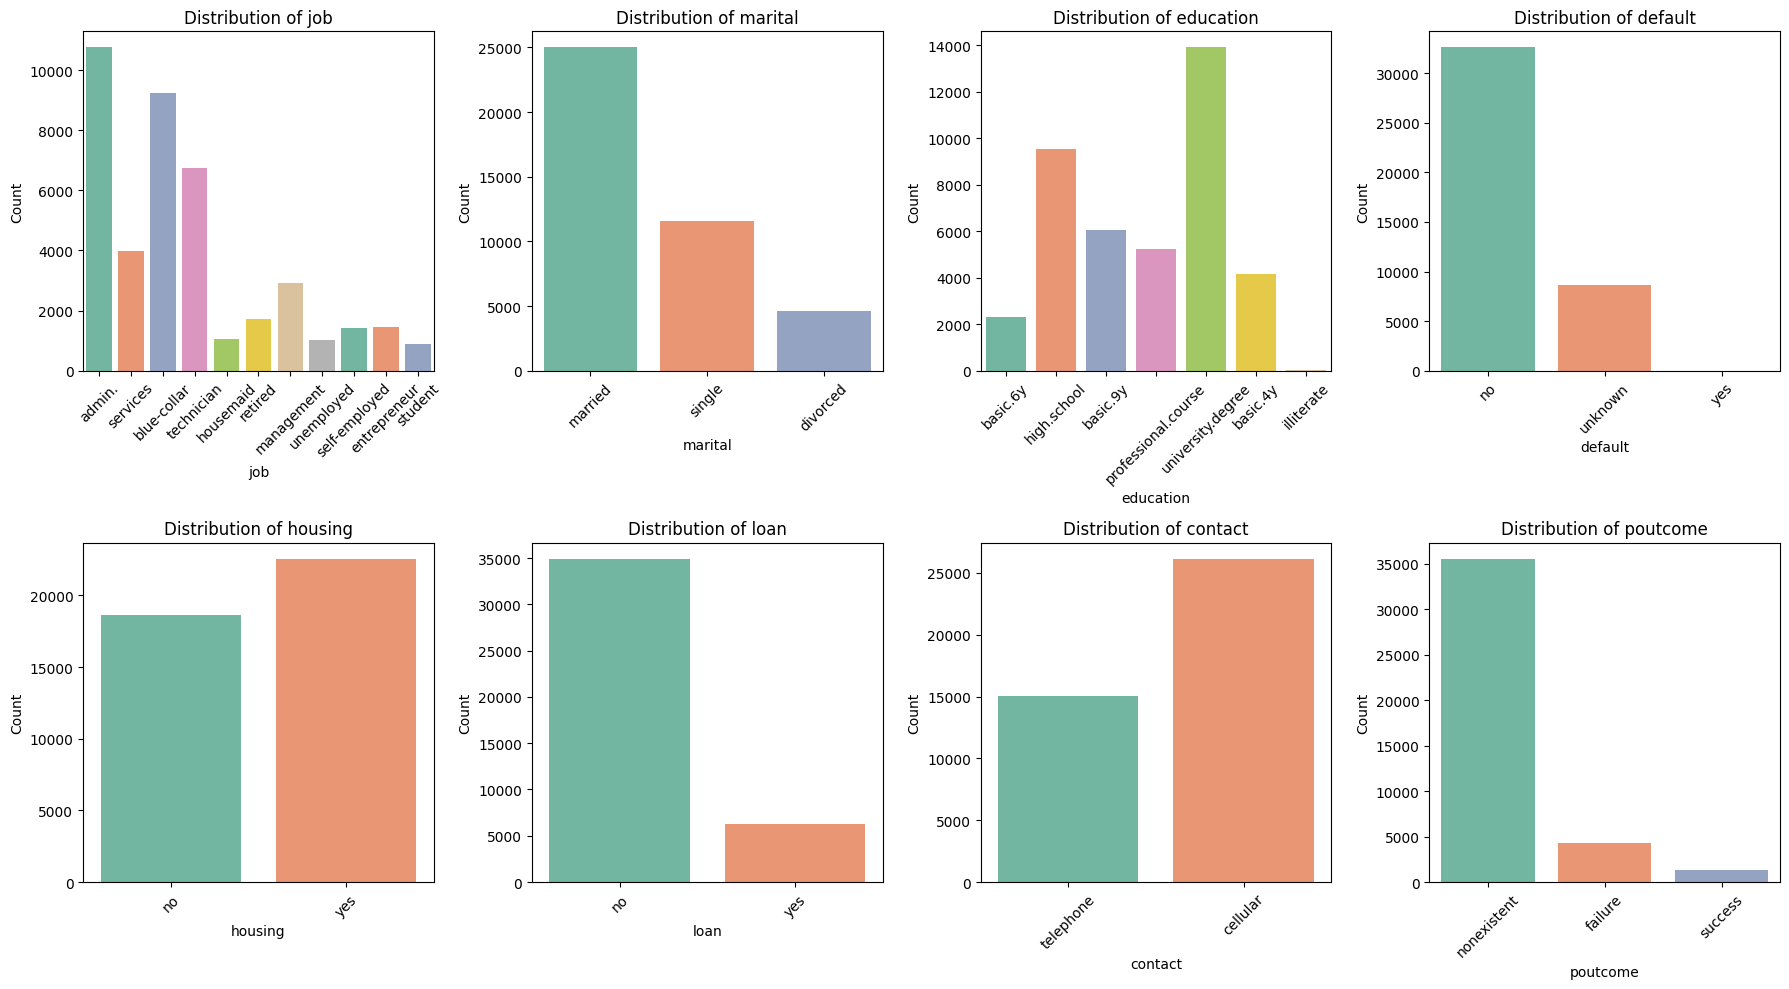

In [34]:
# Count plots for categorical variables
cat_cols = ['job', 'marital', 'education', 'default',
            'housing', 'loan', 'contact', 'poutcome']

fig, axes = plt.subplots(2, 4, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    sns.countplot(data=df, x=col, hue=col, ax=axes[i], palette='Set2', legend=False)
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

#Bivariate Relationship Plots

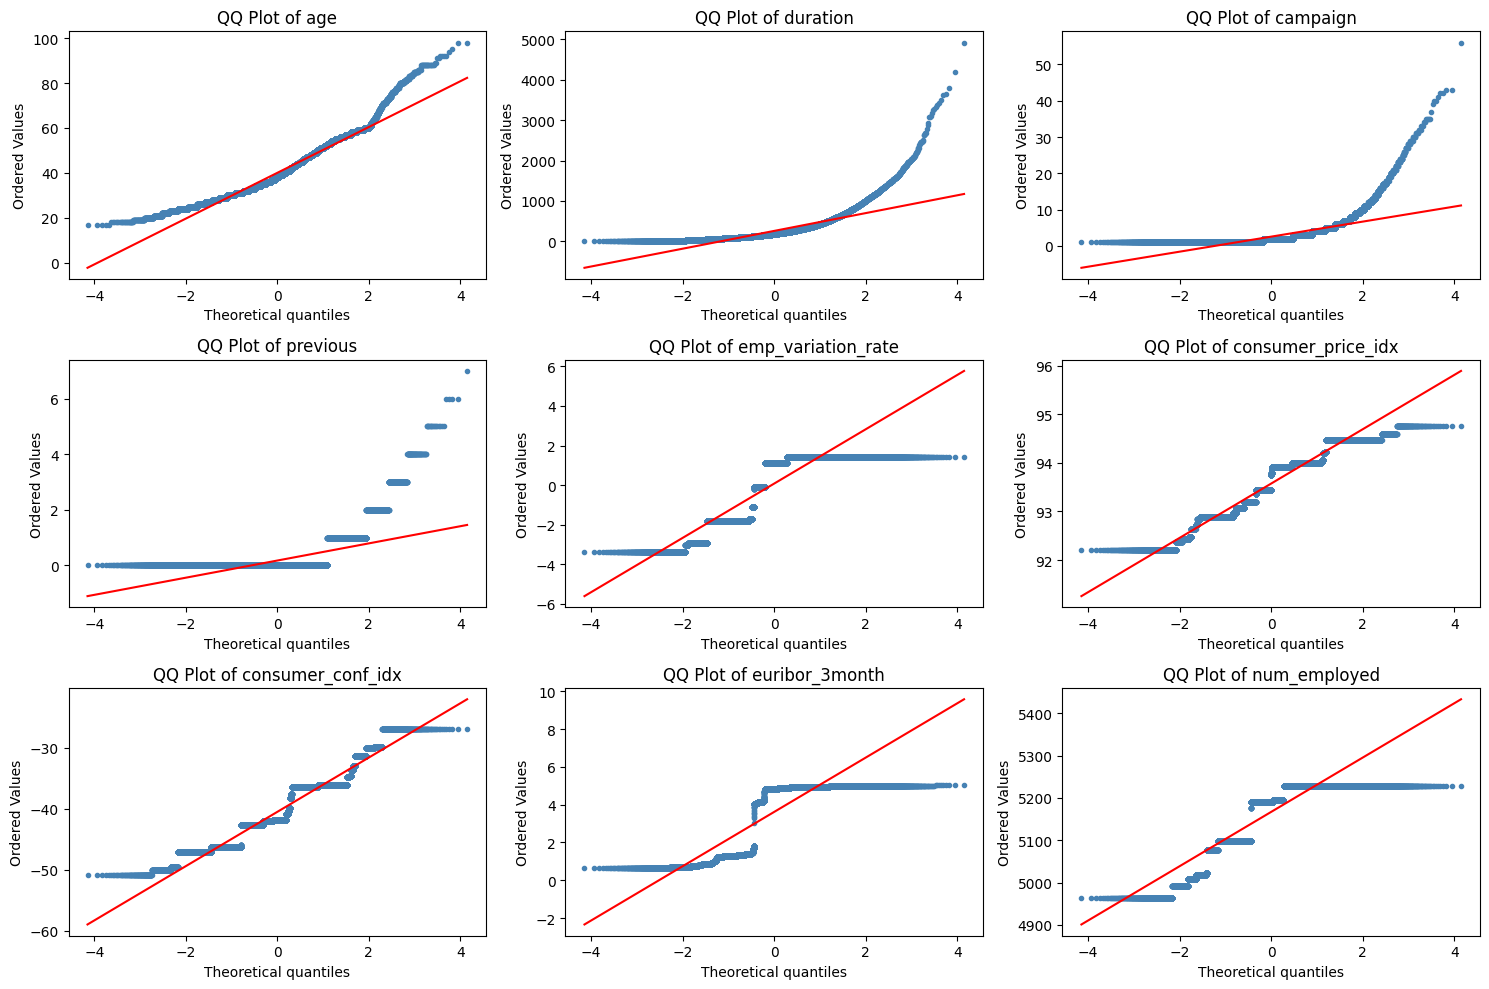

In [35]:
# QQ plots to check normality of numeric variables
fig, axes = plt.subplots(3, 3, figsize=(15, 10))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    stats.probplot(df[col], dist="norm", plot=axes[i])
    axes[i].get_lines()[0].set(color='steelblue', markersize=3)
    axes[i].get_lines()[1].set(color='red')
    axes[i].set_title(f'QQ Plot of {col}')

plt.tight_layout()
plt.show()

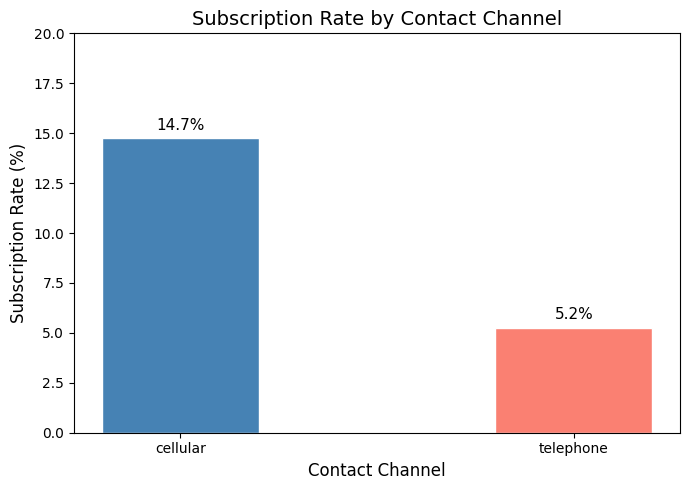

In [36]:
plt.figure(figsize=(7, 5))

contact_rate = df.groupby('contact')['subscribed'].apply(
    lambda x: (x == 'yes').mean() * 100).reset_index()
contact_rate.columns = ['contact', 'subscription_rate']

bars = plt.bar(contact_rate['contact'], contact_rate['subscription_rate'],
               color=['steelblue', 'salmon'], edgecolor='white', width=0.4)

for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=11)

plt.title('Subscription Rate by Contact Channel', fontsize=14)
plt.xlabel('Contact Channel', fontsize=12)
plt.ylabel('Subscription Rate (%)', fontsize=12)
plt.ylim(0, 20)
plt.tight_layout()
plt.show()

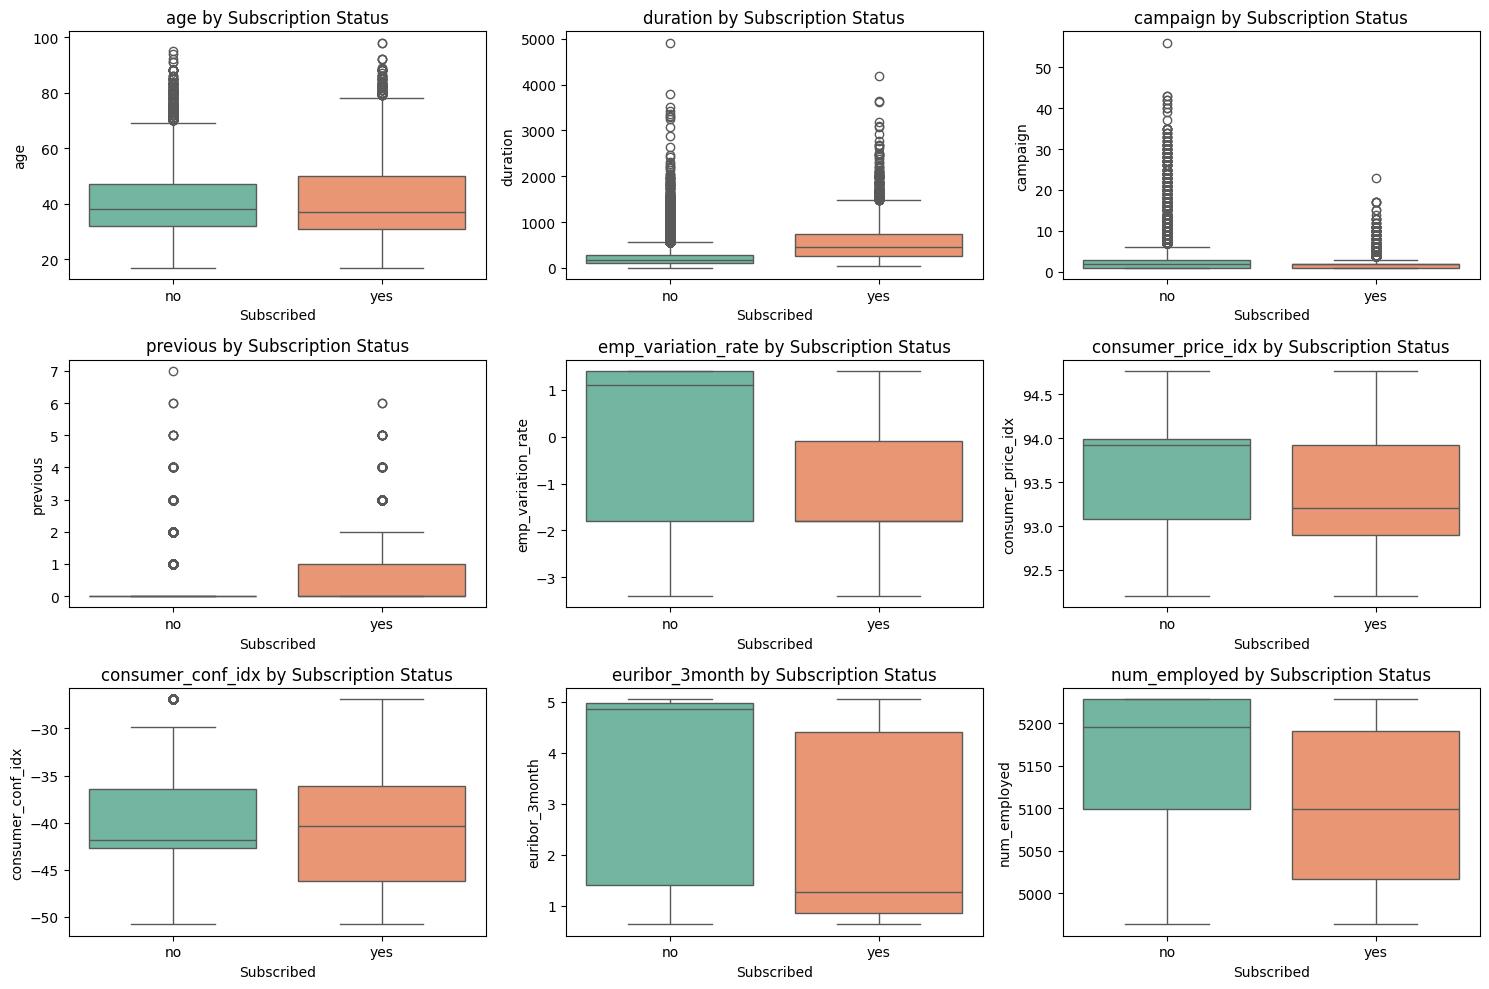

In [37]:
# Box plots to compare numeric variables between subscribers and non-subscribers
fig, axes = plt.subplots(3, 3, figsize=(15, 10))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.boxplot(data=df, x='subscribed', y=col, hue='subscribed',
                ax=axes[i], palette='Set2', legend=False)
    axes[i].set_title(f'{col} by Subscription Status')
    axes[i].set_xlabel('Subscribed')
    axes[i].set_ylabel(col)

plt.tight_layout()
plt.show()

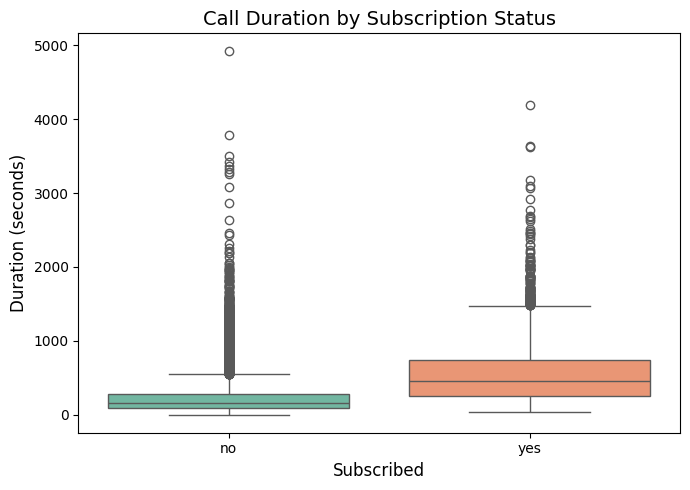

In [38]:
plt.figure(figsize=(7, 5))

sns.boxplot(data=df, x='subscribed', y='duration',
            hue='subscribed', palette= 'Set2',
            legend=False)

plt.title('Call Duration by Subscription Status', fontsize=14)
plt.xlabel('Subscribed', fontsize=12)
plt.ylabel('Duration (seconds)', fontsize=12)
plt.tight_layout()
plt.show()

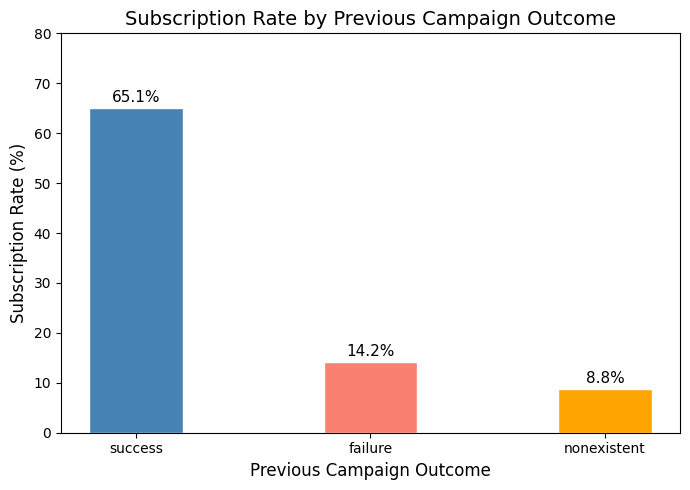

In [39]:
plt.figure(figsize=(7, 5))

poutcome_rate = df.groupby('poutcome')['subscribed'].apply(
    lambda x: (x == 'yes').mean() * 100).reset_index()
poutcome_rate.columns = ['poutcome', 'subscription_rate']
poutcome_rate = poutcome_rate.sort_values('subscription_rate', ascending=False)

bars = plt.bar(poutcome_rate['poutcome'], poutcome_rate['subscription_rate'],
               color=['steelblue', 'salmon', 'orange'], edgecolor='white', width=0.4)

for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=11)

plt.title('Subscription Rate by Previous Campaign Outcome', fontsize=14)
plt.xlabel('Previous Campaign Outcome', fontsize=12)
plt.ylabel('Subscription Rate (%)', fontsize=12)
plt.ylim(0, 80)
plt.tight_layout()
plt.show()

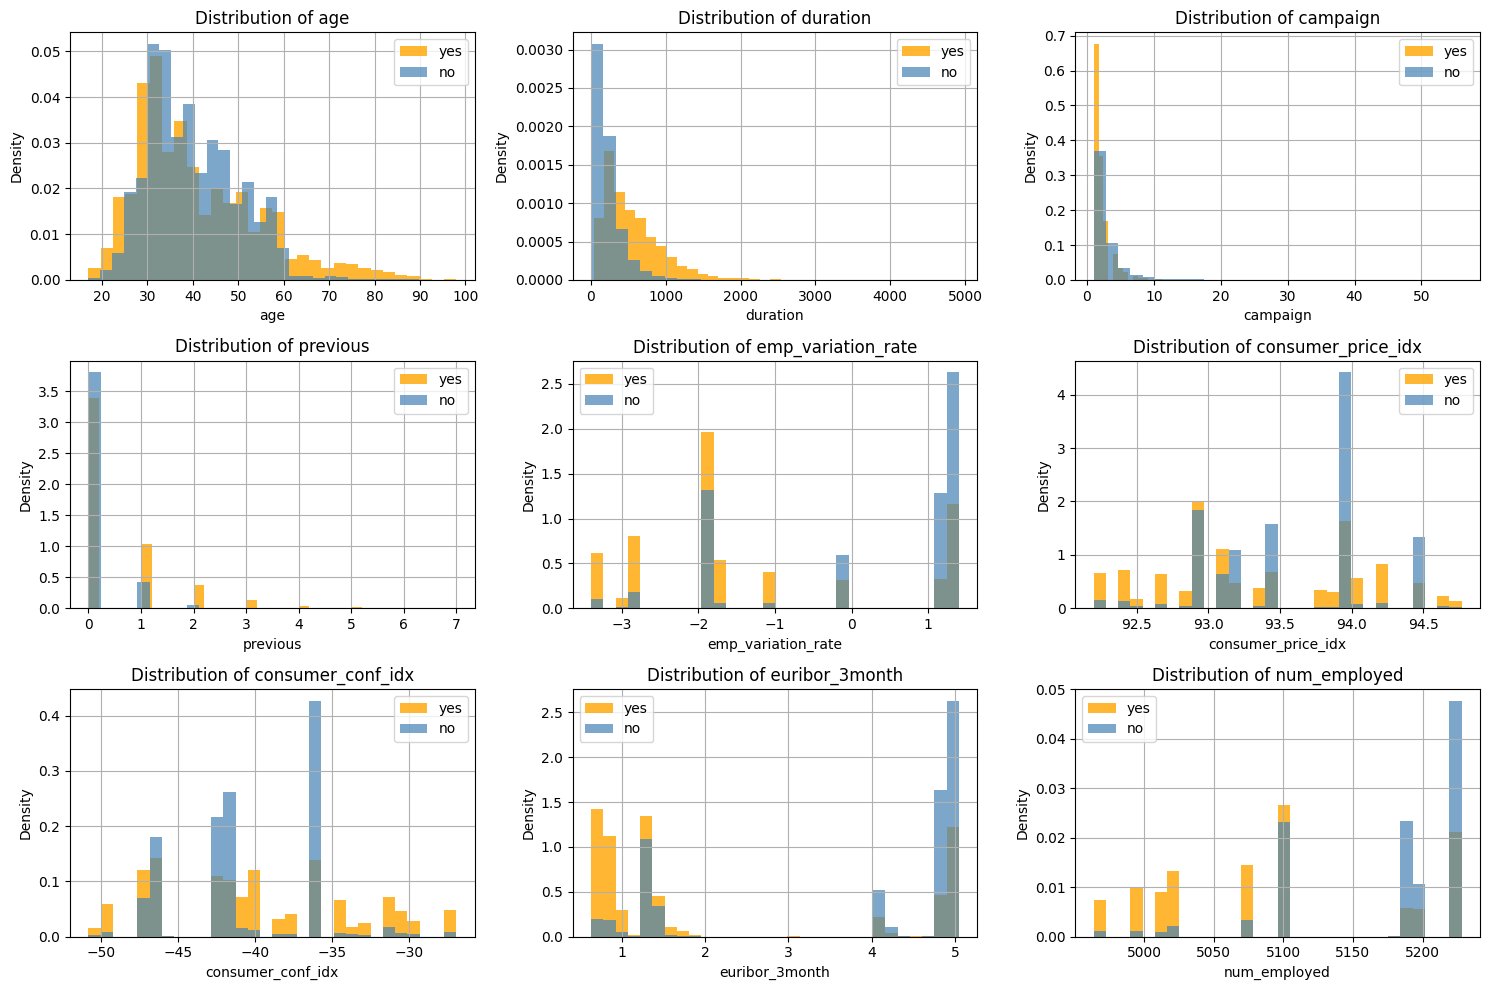

In [40]:
# Histogram for each numeric variable by subscription status
fig, axes = plt.subplots(3, 3, figsize=(15, 10))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    df[df['subscribed'] == 'yes'][col].hist(bins=30, ax=axes[i], alpha=0.8,
                                             color='orange', label='yes', density=True)
    df[df['subscribed'] == 'no'][col].hist(bins=30, ax=axes[i], alpha=0.7,
                                            color='steelblue', label='no', density=True)
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Density')
    axes[i].legend()

plt.tight_layout()
plt.show()

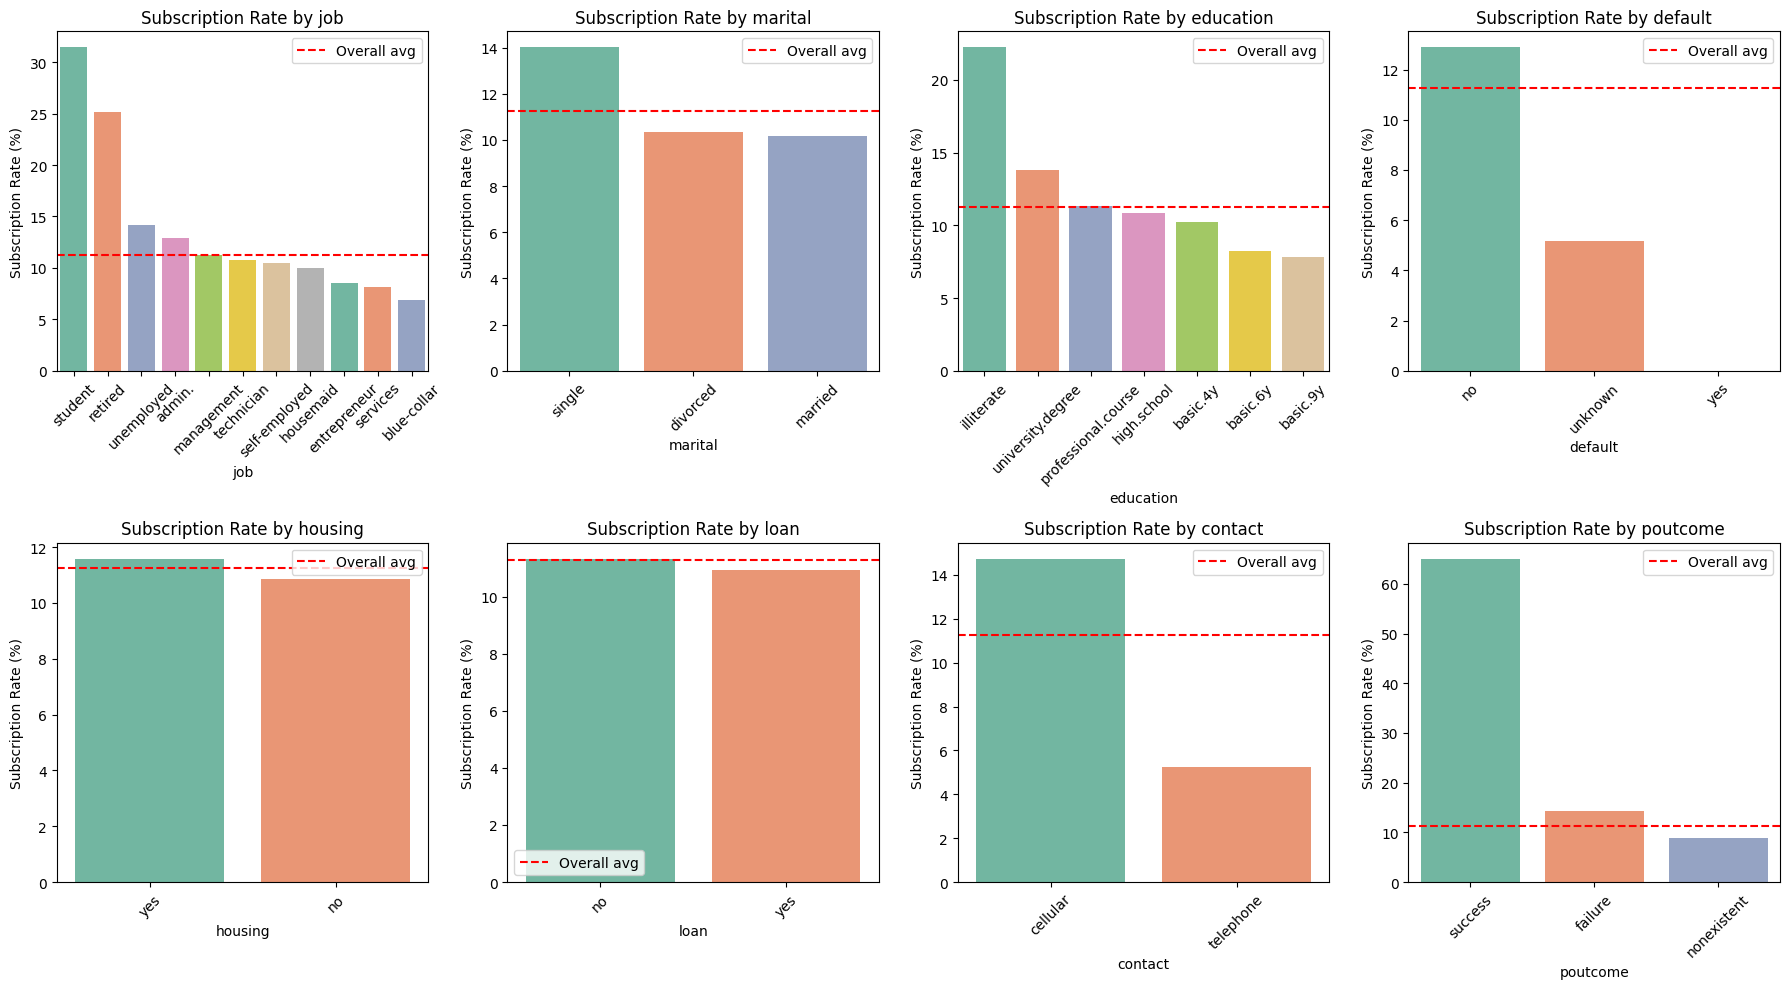

In [41]:
# Subscription rate by categorical variables
cat_cols = ['job', 'marital', 'education', 'default',
            'housing', 'loan', 'contact', 'poutcome']

fig, axes = plt.subplots(2, 4, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    rate = df.groupby(col)['subscribed'].apply(lambda x: (x == 'yes').mean() * 100)
    rate = rate.sort_values(ascending=False).reset_index()
    rate.columns = [col, 'subscription_rate']
    sns.barplot(data=rate, x=col, y='subscription_rate', hue=col,
                ax=axes[i], palette='Set2', legend=False)
    axes[i].set_title(f'Subscription Rate by {col}')
    axes[i].set_ylabel('Subscription Rate (%)')
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].axhline(y=df['subscribed'].eq('yes').mean()*100,
                    color='red', linestyle='--', label='Overall avg')
    axes[i].legend()

plt.tight_layout()
plt.show()

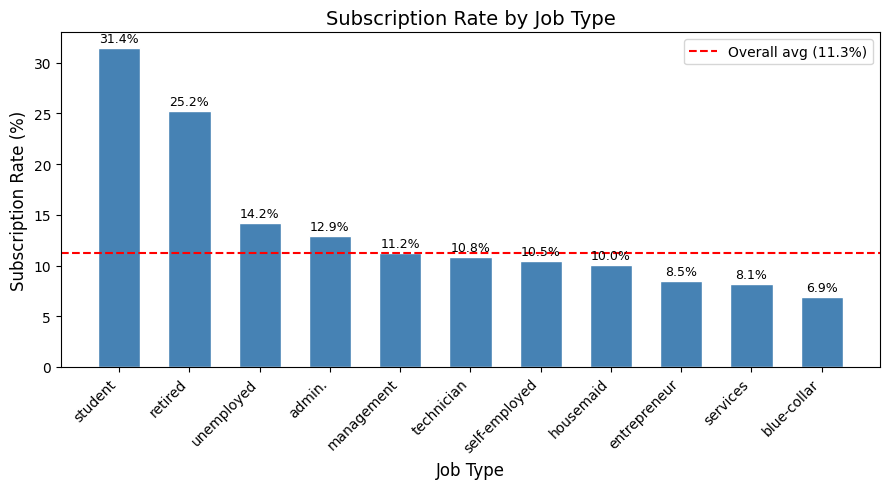

In [42]:
plt.figure(figsize=(9, 5))

job_rate = df.groupby('job')['subscribed'].apply(
    lambda x: (x == 'yes').mean() * 100).reset_index()
job_rate.columns = ['job', 'subscription_rate']
job_rate = job_rate.sort_values('subscription_rate', ascending=False)

bars = plt.bar(job_rate['job'], job_rate['subscription_rate'],
               color='steelblue', edgecolor='white', width=0.6)

for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=9)

plt.axhline(y=df['subscribed'].eq('yes').mean()*100,
            color='red', linestyle='--', label='Overall avg (11.3%)')
plt.title('Subscription Rate by Job Type', fontsize=14)
plt.xlabel('Job Type', fontsize=12)
plt.ylabel('Subscription Rate (%)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend()
plt.tight_layout()
plt.show()

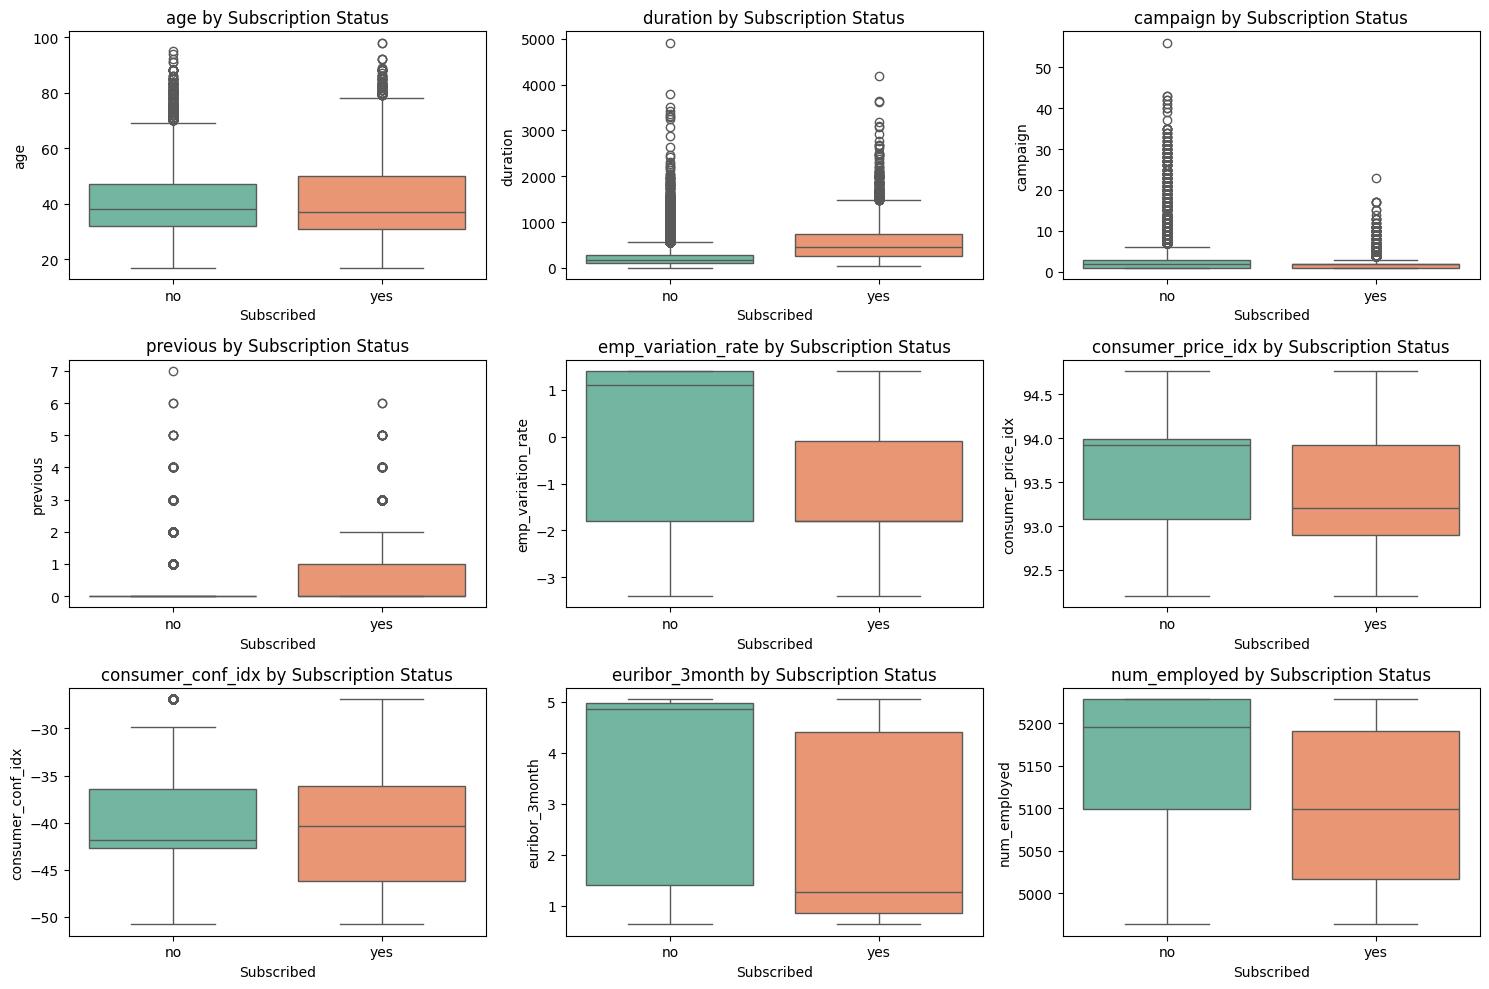

In [43]:
# Box plots to compare numeric variables between subscribers and non-subscribers
fig, axes = plt.subplots(3, 3, figsize=(15, 10))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.boxplot(data=df, x='subscribed', y=col, hue='subscribed',
                ax=axes[i], palette='Set2', legend=False)
    axes[i].set_title(f'{col} by Subscription Status')
    axes[i].set_xlabel('Subscribed')
    axes[i].set_ylabel(col)

plt.tight_layout()
plt.show()

# 6. Variable Transformation

In [44]:
# duration and campaign are highly skewed so we apply log transformation
import numpy as np

df['log_duration'] = np.log(df['duration'])
df['log_campaign'] = np.log(df['campaign'])

print("Skewness before transformation:")
print(f"  duration: {df['duration'].skew().round(2)}")
print(f"  campaign: {df['campaign'].skew().round(2)}")

print("\nSkewness after transformation:")
print(f"  log_duration: {df['log_duration'].skew().round(2)}")
print(f"  log_campaign: {df['log_campaign'].skew().round(2)}")

Skewness before transformation:
  duration: 3.26
  campaign: 4.76

Skewness after transformation:
  log_duration: -0.46
  log_campaign: 0.92


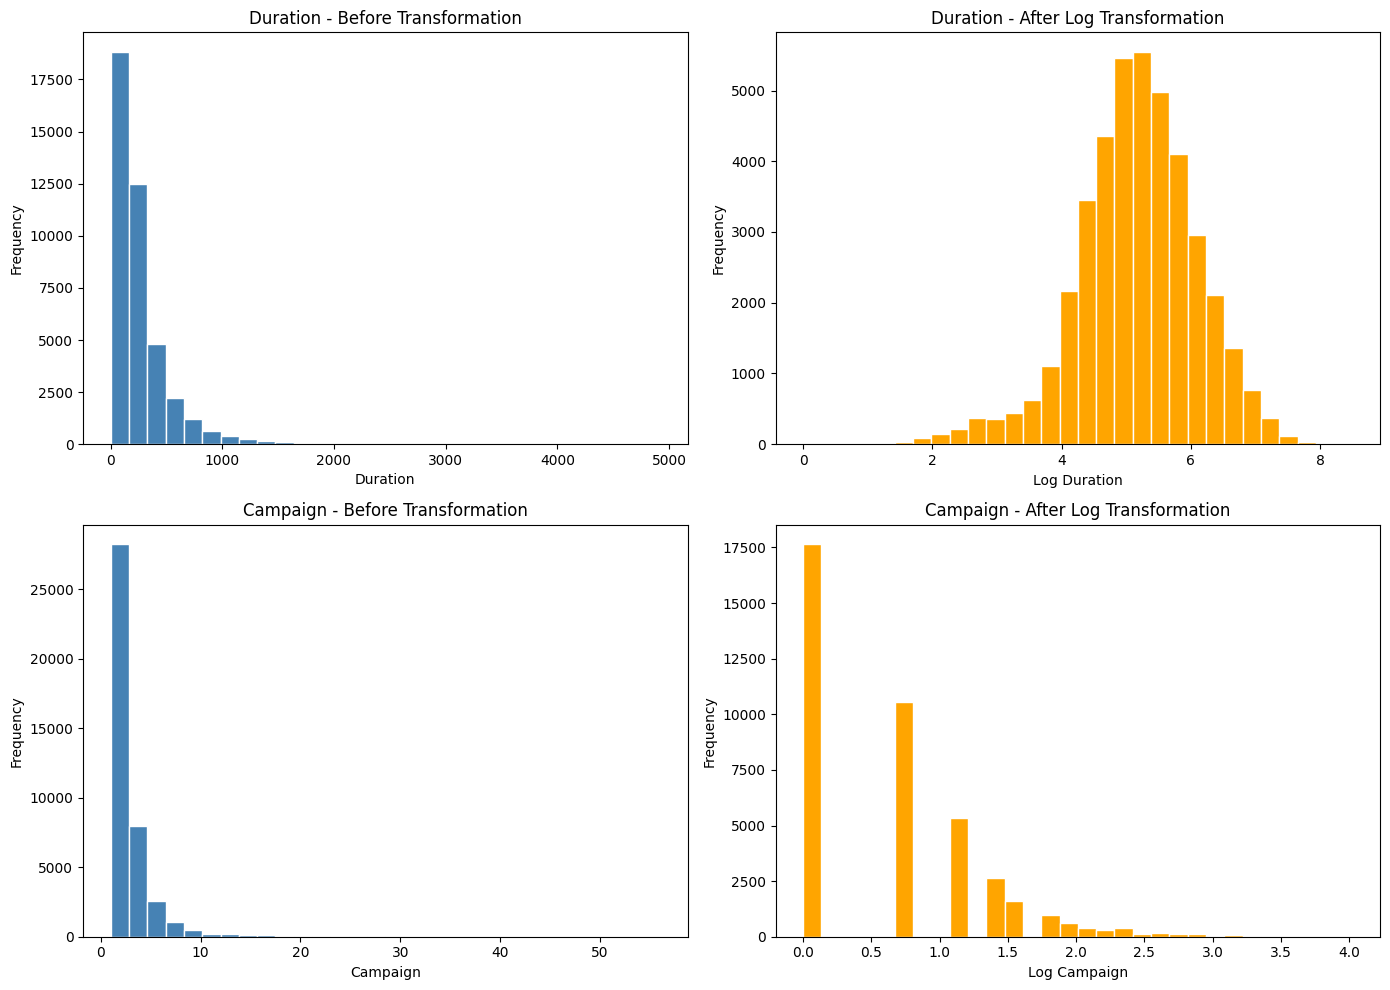

In [45]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Duration before
axes[0, 0].hist(df['duration'], bins=30, color='steelblue', edgecolor='white')
axes[0, 0].set_title('Duration - Before Transformation')
axes[0, 0].set_xlabel('Duration')
axes[0, 0].set_ylabel('Frequency')

# Duration after
axes[0, 1].hist(df['log_duration'], bins=30, color='orange', edgecolor='white')
axes[0, 1].set_title('Duration - After Log Transformation')
axes[0, 1].set_xlabel('Log Duration')
axes[0, 1].set_ylabel('Frequency')

# Campaign before
axes[1, 0].hist(df['campaign'], bins=30, color='steelblue', edgecolor='white')
axes[1, 0].set_title('Campaign - Before Transformation')
axes[1, 0].set_xlabel('Campaign')
axes[1, 0].set_ylabel('Frequency')

# Campaign after
axes[1, 1].hist(df['log_campaign'], bins=30, color='orange', edgecolor='white')
axes[1, 1].set_title('Campaign - After Log Transformation')
axes[1, 1].set_xlabel('Log Campaign')
axes[1, 1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

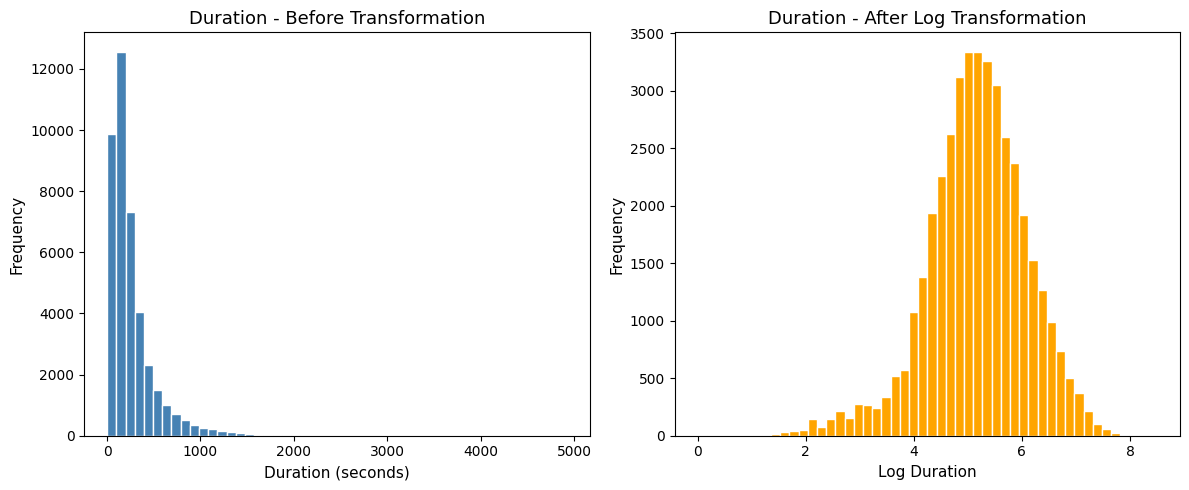

In [46]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].hist(df['duration'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Duration - Before Transformation', fontsize=13)
axes[0].set_xlabel('Duration (seconds)', fontsize=11)
axes[0].set_ylabel('Frequency', fontsize=11)

axes[1].hist(df['log_duration'], bins=50, color='orange', edgecolor='white')
axes[1].set_title('Duration - After Log Transformation', fontsize=13)
axes[1].set_xlabel('Log Duration', fontsize=11)
axes[1].set_ylabel('Frequency', fontsize=11)

plt.tight_layout()
plt.show()

In [47]:
# campaign starts from 1 so log works, but let's check
print(df['campaign'].min())
print(df['log_campaign'].value_counts().head())

1
log_campaign
0.000000    17637
0.693147    10567
1.098612     5339
1.386294     2650
1.609438     1599
Name: count, dtype: int64


#Section 7: Dependence Measures

Columns recreated successfully


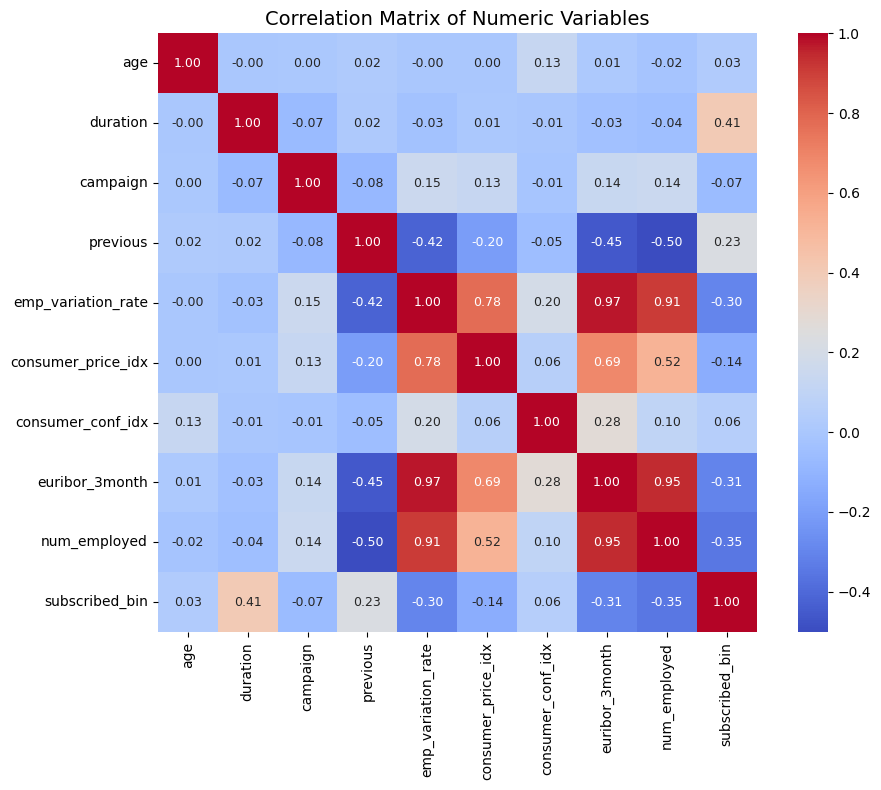

In [48]:
# Recreate necessary columns
df['subscribed_bin'] = (df['subscribed'] == 'yes').astype(int)
df['log_duration'] = np.log(df['duration'])
df['log_campaign'] = np.log(df['campaign'])

print("Columns recreated successfully")

plt.figure(figsize=(10, 8))

numeric_cols_corr = ['age', 'duration', 'campaign', 'previous',
                     'emp_variation_rate', 'consumer_price_idx',
                     'consumer_conf_idx', 'euribor_3month',
                     'num_employed', 'subscribed_bin']

correlation_matrix = df[numeric_cols_corr].corr()

sns.heatmap(correlation_matrix, annot=True, fmt='.2f',
            cmap='coolwarm', square=True,
            annot_kws={'size': 9})

plt.title('Correlation Matrix of Numeric Variables', fontsize=14)
plt.tight_layout()
plt.show()

In [49]:
# Chi-squared test for categorical variables vs subscribed
cat_cols = ['job', 'marital', 'education', 'default',
            'housing', 'loan', 'contact', 'poutcome']

print(f"{'Variable':<15} {'Chi2':>10} {'p-value':>10} {'Significant?':>15}")
print("-" * 55)

for col in cat_cols:
    ct = pd.crosstab(df[col], df['subscribed'])
    chi2, p, dof, _ = chi2_contingency(ct)
    sig = "Yes" if p < 0.05 else "No"
    print(f"{col:<15} {chi2:>10.1f} {p:>10.4f} {sig:>15}")

Variable              Chi2    p-value    Significant?
-------------------------------------------------------
job                  958.3     0.0000             Yes
marital              121.0     0.0000             Yes
education            191.7     0.0000             Yes
default              406.3     0.0000             Yes
housing                5.0     0.0249             Yes
loan                   0.8     0.3812              No
contact              861.2     0.0000             Yes
poutcome            4217.5     0.0000             Yes
